In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Set font size and style in matplotlib
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

# Color palette for AIRKO and MIRKO
colors_AIRKO = ['grey', 'lightcoral']
colors_MIRKO = ['grey', 'steelblue']

## Setup Extended Model

In [2]:
# Reload module to get latest changes
import importlib
import sys
if 'multi_nutrient_model_ext' in sys.modules:
    importlib.reload(sys.modules['multi_nutrient_model_ext'])

from multi_nutrient_model_ext import (
    ref_parameters as ref_parameters_ext,
    perturbation_dynamics as perturbation_dynamics_ext,
    steady_state as steady_state_ext,
    AMINO_ACIDS,
    PARAMETER_NAMES as PARAMETER_NAMES_EXT
)

# Extended model parameters
K_i_ketogenesis = 0.2
p_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)

# State variable names for extended model
VARIABLE_NAME_EXT = ['L', 'G', 'F', 'K', 'I', 'IA', 'GCG', 'GCGA'] + AMINO_ACIDS

# Insulin baseline (from extended model)
# Get initial state and extract insulin
x0_ext_init = steady_state_ext(p_ext)
I0_ext = x0_ext_init[4]  # Insulin at index 4

# ATP scaling
PO2 = 5.0
vO2 = 2000 * 0.7
vATP = PO2 * vO2
vE = vATP

## Setup Base Model

In [3]:
# Import base model
import sys
sys.path.insert(0, '../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    perturbation_dynamics as perturbation_dynamics_base,
    steady_state as steady_state_base,
    I0 as I0_base,
    PARAMETER_NAMES as PARAMETER_NAMES_BASE
)

# Base model parameters
p_base = ref_parameters_base(K_i_ketogenesis=K_i_ketogenesis)

# State variable names for base model
VARIABLE_NAME_BASE = ['L', 'G', 'F', 'K', 'I', 'IA']

## GTT Simulation - Glucose Tolerance Test

In [4]:
# =============================================================================
# Extended model GTT
# =============================================================================

# Phase 1: Glucose infusion (0-15 min)
time_1 = np.linspace(0, 15, 100)
X_1_ext, F_1_ext = perturbation_dynamics_ext(time_1, x0=None, p=p_ext, R_glucose=0.06)

# Phase 2: Recovery (15-120 min)
time_2 = np.linspace(15, 120, 100)
x0_phase2 = X_1_ext.iloc[-1][VARIABLE_NAME_EXT].values
X_2_ext, F_2_ext = perturbation_dynamics_ext(time_2, x0=x0_phase2, p=p_ext, R_glucose=0.0)

# Combine phases
GTT_ext = pd.concat([X_1_ext, X_2_ext], axis=0, ignore_index=True)

# Scale to physiological units
GTT_ext['G'] = GTT_ext['G'] * 7.0   # mM
GTT_ext['F'] = GTT_ext['F'] * 0.5   # mM
GTT_ext['K'] = GTT_ext['K'] * 0.5   # mM
GTT_ext['L'] = GTT_ext['L'] * 0.7   # mM
GTT_ext['I'] = GTT_ext['I'] / I0_ext * 0.4  # nM

# =============================================================================
# Base model GTT
# =============================================================================

# Phase 1: Glucose infusion (0-15 min)
time_1 = np.linspace(0, 15, 100)
X_1_base, F_1_base = perturbation_dynamics_base(time_1, 1.0, p=p_base, R_glucose=0.06)

# Phase 2: Recovery (15-120 min)
time_2 = np.linspace(15, 120, 100)
x0_phase2 = X_1_base.iloc[-1][VARIABLE_NAME_BASE].values
X_2_base, F_2_base = perturbation_dynamics_base(time_2, 1.0, X0=x0_phase2, p=p_base, R_glucose=0.0)

# Combine phases
GTT_base = pd.concat([X_1_base, X_2_base], axis=0, ignore_index=True)

# Scale to physiological units
GTT_base['G'] = GTT_base['G'] * 7.0   # mM
GTT_base['F'] = GTT_base['F'] * 0.5   # mM
GTT_base['K'] = GTT_base['K'] * 0.5   # mM
GTT_base['L'] = GTT_base['L'] * 0.7   # mM
GTT_base['I'] = GTT_base['I'] / I0_base * 0.4  # nM

## ITT Simulation - Insulin Tolerance Test

In [5]:
# =============================================================================
# Extended model ITT
# =============================================================================

# Phase 1: Baseline (0-1 min)
time_1 = np.linspace(0, 1, 100)
X_1_ext, F_1_ext = perturbation_dynamics_ext(time_1, x0=None, p=p_ext)

# Phase 2: Insulin bolus (1-120 min)
time_2 = np.linspace(1, 120, 100)
x0_bolus = steady_state_ext(p_ext)
x0_bolus[4] = I0_ext * 60  # 60-fold increase in insulin
X_2_ext, F_2_ext = perturbation_dynamics_ext(time_2, x0=x0_bolus, p=p_ext)

# Combine phases
ITT_ext = pd.concat([X_1_ext, X_2_ext], axis=0, ignore_index=True)

# Scale to physiological units
ITT_ext['G'] = ITT_ext['G'] * 7.0   # mM
ITT_ext['F'] = ITT_ext['F'] * 0.5   # mM
ITT_ext['K'] = ITT_ext['K'] * 0.5   # mM
ITT_ext['L'] = ITT_ext['L'] * 0.7   # mM
ITT_ext['I'] = ITT_ext['I'] / I0_ext * 0.4  # nM

# =============================================================================
# Base model ITT
# =============================================================================

# Phase 1: Baseline (0-1 min)
time_1 = np.linspace(0, 1, 100)
X_1_base, F_1_base = perturbation_dynamics_base(time_1, 1.0, p=p_base)

# Phase 2: Insulin bolus (1-120 min)
time_2 = np.linspace(1, 120, 100)
x0_bolus = steady_state_base(1, p_base)
x0_bolus[-2] = I0_base * 60  # 60-fold increase in insulin
X_2_base, F_2_base = perturbation_dynamics_base(time_2, 1.0, X0=x0_bolus, p=p_base)

# Combine phases
ITT_base = pd.concat([X_1_base, X_2_base], axis=0, ignore_index=True)

# Scale to physiological units
ITT_base['G'] = ITT_base['G'] * 7.0   # mM
ITT_base['F'] = ITT_base['F'] * 0.5   # mM
ITT_base['K'] = ITT_base['K'] * 0.5   # mM
ITT_base['L'] = ITT_base['L'] * 0.7   # mM
ITT_base['I'] = ITT_base['I'] / I0_base * 0.4  # nM

## Adipose Insulin Receptor Knockout (AIRKO)

In [6]:
# Extended model AIRKO - disable insulin action on lipolysis
p_AIRKO_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)
p_AIRKO_ext[PARAMETER_NAMES_EXT.index('insulin_action_lipolysis')] = 0.0
x0_AIRKO_ext = steady_state_ext(p_AIRKO_ext)

# GTT - AIRKO Extended
time_1 = np.linspace(0, 15, 100)
X_1_ext_AIRKO, _ = perturbation_dynamics_ext(time_1, x0=x0_AIRKO_ext, p=p_AIRKO_ext, R_glucose=0.06)

time_2 = np.linspace(15, 120, 100)
x0_phase2 = X_1_ext_AIRKO.iloc[-1][VARIABLE_NAME_EXT].values
X_2_ext_AIRKO, _ = perturbation_dynamics_ext(time_2, x0=x0_phase2, p=p_AIRKO_ext, R_glucose=0.0)

GTT_ext_AIRKO = pd.concat([X_1_ext_AIRKO, X_2_ext_AIRKO], axis=0, ignore_index=True)
GTT_ext_AIRKO['G'] = GTT_ext_AIRKO['G'] * 7.0

# ITT - AIRKO Extended
time_1 = np.linspace(0, 1, 100)
X_1_ext_AIRKO, _ = perturbation_dynamics_ext(time_1, x0=x0_AIRKO_ext, p=p_AIRKO_ext)

time_2 = np.linspace(1, 120, 100)
x0_bolus = x0_AIRKO_ext.copy()
x0_bolus[4] = I0_ext * 60
X_2_ext_AIRKO, _ = perturbation_dynamics_ext(time_2, x0=x0_bolus, p=p_AIRKO_ext)

ITT_ext_AIRKO = pd.concat([X_1_ext_AIRKO, X_2_ext_AIRKO], axis=0, ignore_index=True)
ITT_ext_AIRKO['G'] = ITT_ext_AIRKO['G'] * 7.0

# Base model AIRKO
p_AIRKO_base = p_base.copy()
p_AIRKO_base[PARAMETER_NAMES_BASE.index('insulin_action_lipolysis')] = False
x0_AIRKO_base = steady_state_base(1, p_AIRKO_base)

# GTT - AIRKO Base
time_1 = np.linspace(0, 15, 100)
X_1_base_AIRKO, _ = perturbation_dynamics_base(time_1, 1.0, X0=x0_AIRKO_base, p=p_AIRKO_base, R_glucose=0.06)

time_2 = np.linspace(15, 120, 100)
x0_phase2 = X_1_base_AIRKO.iloc[-1][VARIABLE_NAME_BASE].values
X_2_base_AIRKO, _ = perturbation_dynamics_base(time_2, 1.0, X0=x0_phase2, p=p_AIRKO_base, R_glucose=0.0)

GTT_base_AIRKO = pd.concat([X_1_base_AIRKO, X_2_base_AIRKO], axis=0, ignore_index=True)
GTT_base_AIRKO['G'] = GTT_base_AIRKO['G'] * 7.0

# ITT - AIRKO Base
time_1 = np.linspace(0, 1, 100)
X_1_base_AIRKO, _ = perturbation_dynamics_base(time_1, 1.0, X0=x0_AIRKO_base, p=p_AIRKO_base)

time_2 = np.linspace(1, 120, 100)
x0_bolus = x0_AIRKO_base.copy()
x0_bolus[-2] = I0_base * 60
X_2_base_AIRKO, _ = perturbation_dynamics_base(time_2, 1.0, X0=x0_bolus, p=p_AIRKO_base)

ITT_base_AIRKO = pd.concat([X_1_base_AIRKO, X_2_base_AIRKO], axis=0, ignore_index=True)
ITT_base_AIRKO['G'] = ITT_base_AIRKO['G'] * 7.0

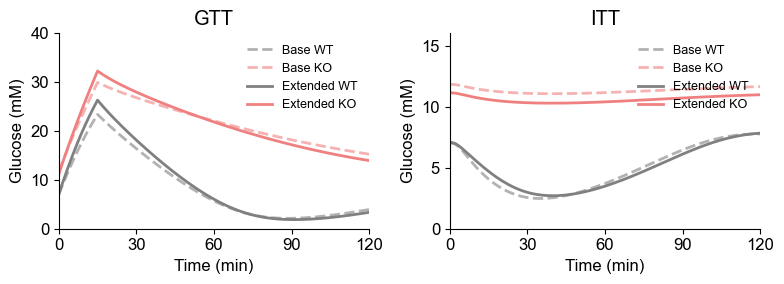

In [7]:
# Plot comparison of WT and AIRKO for both models
f, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

# GTT comparison
ax[0].plot(GTT_base['time'], GTT_base['G'], color=colors_AIRKO[0], linewidth=2, 
           linestyle='--', label='Base WT', alpha=0.6)
ax[0].plot(GTT_base_AIRKO['time'], GTT_base_AIRKO['G'], color=colors_AIRKO[1], linewidth=2, 
           linestyle='--', label='Base KO', alpha=0.6)
ax[0].plot(GTT_ext['time'], GTT_ext['G'], color=colors_AIRKO[0], linewidth=2, 
           linestyle='-', label='Extended WT')
ax[0].plot(GTT_ext_AIRKO['time'], GTT_ext_AIRKO['G'], color=colors_AIRKO[1], linewidth=2, 
           linestyle='-', label='Extended KO')
ax[0].set_ylim(0, 40)
ax[0].set_xlim(0, 120)
ax[0].set_xticks([0, 30, 60, 90, 120])
ax[0].set_ylabel('Glucose (mM)')
ax[0].set_xlabel('Time (min)')
ax[0].set_title('GTT')
ax[0].legend(frameon=False, loc='upper right', fontsize=9)

# ITT comparison
ax[1].plot(ITT_base['time'], ITT_base['G'], color=colors_AIRKO[0], linewidth=2, 
           linestyle='--', label='Base WT', alpha=0.6)
ax[1].plot(ITT_base_AIRKO['time'], ITT_base_AIRKO['G'], color=colors_AIRKO[1], linewidth=2, 
           linestyle='--', label='Base KO', alpha=0.6)
ax[1].plot(ITT_ext['time'], ITT_ext['G'], color=colors_AIRKO[0], linewidth=2, 
           linestyle='-', label='Extended WT')
ax[1].plot(ITT_ext_AIRKO['time'], ITT_ext_AIRKO['G'], color=colors_AIRKO[1], linewidth=2, 
           linestyle='-', label='Extended KO')
ax[1].set_ylim(0, 16)
ax[1].set_xlim(0, 120)
ax[1].set_xticks([0, 30, 60, 90, 120])
ax[1].set_ylabel('Glucose (mM)')
ax[1].set_xlabel('Time (min)')
ax[1].set_title('ITT')
ax[1].legend(frameon=False, loc='upper right', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('./output/GTT_ITT_AIRKO_comparison.svg', bbox_inches='tight')
plt.show()

## Muscle Insulin Receptor Knockout (MIRKO)

In [8]:
# Extended model MIRKO - disable insulin action on glycolysis
p_MIRKO_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)
p_MIRKO_ext[PARAMETER_NAMES_EXT.index('insulin_action_glycolysis')] = 0.0
x0_MIRKO_ext = steady_state_ext(p_MIRKO_ext)

# GTT - MIRKO Extended
time_1 = np.linspace(0, 15, 100)
X_1_ext_MIRKO, _ = perturbation_dynamics_ext(time_1, x0=x0_MIRKO_ext, p=p_MIRKO_ext, R_glucose=0.06)

time_2 = np.linspace(15, 120, 100)
x0_phase2 = X_1_ext_MIRKO.iloc[-1][VARIABLE_NAME_EXT].values
X_2_ext_MIRKO, _ = perturbation_dynamics_ext(time_2, x0=x0_phase2, p=p_MIRKO_ext, R_glucose=0.0)

GTT_ext_MIRKO = pd.concat([X_1_ext_MIRKO, X_2_ext_MIRKO], axis=0, ignore_index=True)
GTT_ext_MIRKO['G'] = GTT_ext_MIRKO['G'] * 7.0

# ITT - MIRKO Extended
time_1 = np.linspace(0, 1, 100)
X_1_ext_MIRKO, _ = perturbation_dynamics_ext(time_1, x0=x0_MIRKO_ext, p=p_MIRKO_ext)

time_2 = np.linspace(1, 100, 100)
x0_bolus = x0_MIRKO_ext.copy()
x0_bolus[4] = I0_ext * 60
X_2_ext_MIRKO, _ = perturbation_dynamics_ext(time_2, x0=x0_bolus, p=p_MIRKO_ext)

ITT_ext_MIRKO = pd.concat([X_1_ext_MIRKO, X_2_ext_MIRKO], axis=0, ignore_index=True)
ITT_ext_MIRKO['G'] = ITT_ext_MIRKO['G'] * 7.0

# Base model MIRKO
p_MIRKO_base = p_base.copy()
p_MIRKO_base[PARAMETER_NAMES_BASE.index('insulin_action_glycolysis')] = False
x0_MIRKO_base = steady_state_base(1, p_MIRKO_base)

# GTT - MIRKO Base
time_1 = np.linspace(0, 15, 100)
X_1_base_MIRKO, _ = perturbation_dynamics_base(time_1, 1.0, X0=x0_MIRKO_base, p=p_MIRKO_base, R_glucose=0.06)

time_2 = np.linspace(15, 120, 100)
x0_phase2 = X_1_base_MIRKO.iloc[-1][VARIABLE_NAME_BASE].values
X_2_base_MIRKO, _ = perturbation_dynamics_base(time_2, 1.0, X0=x0_phase2, p=p_MIRKO_base, R_glucose=0.0)

GTT_base_MIRKO = pd.concat([X_1_base_MIRKO, X_2_base_MIRKO], axis=0, ignore_index=True)
GTT_base_MIRKO['G'] = GTT_base_MIRKO['G'] * 7.0

# ITT - MIRKO Base
time_1 = np.linspace(0, 1, 100)
X_1_base_MIRKO, _ = perturbation_dynamics_base(time_1, 1.0, X0=x0_MIRKO_base, p=p_MIRKO_base)

time_2 = np.linspace(1, 100, 100)
x0_bolus = x0_MIRKO_base.copy()
x0_bolus[-2] = I0_base * 60
X_2_base_MIRKO, _ = perturbation_dynamics_base(time_2, 1.0, X0=x0_bolus, p=p_MIRKO_base)

ITT_base_MIRKO = pd.concat([X_1_base_MIRKO, X_2_base_MIRKO], axis=0, ignore_index=True)
ITT_base_MIRKO['G'] = ITT_base_MIRKO['G'] * 7.0

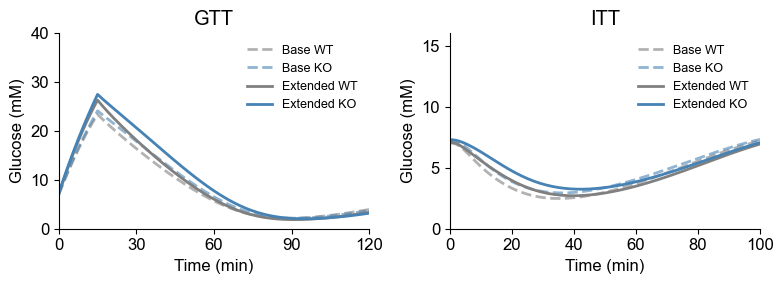

In [9]:
# Plot comparison of WT and MIRKO for both models
f, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

# GTT comparison
ax[0].plot(GTT_base['time'], GTT_base['G'], color=colors_MIRKO[0], linewidth=2, 
           linestyle='--', label='Base WT', alpha=0.6)
ax[0].plot(GTT_base_MIRKO['time'], GTT_base_MIRKO['G'], color=colors_MIRKO[1], linewidth=2, 
           linestyle='--', label='Base KO', alpha=0.6)
ax[0].plot(GTT_ext['time'], GTT_ext['G'], color=colors_MIRKO[0], linewidth=2, 
           linestyle='-', label='Extended WT')
ax[0].plot(GTT_ext_MIRKO['time'], GTT_ext_MIRKO['G'], color=colors_MIRKO[1], linewidth=2, 
           linestyle='-', label='Extended KO')
ax[0].set_ylim(0, 40)
ax[0].set_xlim(0, 120)
ax[0].set_xticks([0, 30, 60, 90, 120])
ax[0].set_ylabel('Glucose (mM)')
ax[0].set_xlabel('Time (min)')
ax[0].set_title('GTT')
ax[0].legend(frameon=False, loc='upper right', fontsize=9)

# ITT comparison
ax[1].plot(ITT_base['time'], ITT_base['G'], color=colors_MIRKO[0], linewidth=2, 
           linestyle='--', label='Base WT', alpha=0.6)
ax[1].plot(ITT_base_MIRKO['time'], ITT_base_MIRKO['G'], color=colors_MIRKO[1], linewidth=2, 
           linestyle='--', label='Base KO', alpha=0.6)
ax[1].plot(ITT_ext['time'], ITT_ext['G'], color=colors_MIRKO[0], linewidth=2, 
           linestyle='-', label='Extended WT')
ax[1].plot(ITT_ext_MIRKO['time'], ITT_ext_MIRKO['G'], color=colors_MIRKO[1], linewidth=2, 
           linestyle='-', label='Extended KO')
ax[1].set_ylim(0, 16)
ax[1].set_xlim(0, 100)
ax[1].set_xticks([0, 20, 40, 60, 80, 100])
ax[1].set_ylabel('Glucose (mM)')
ax[1].set_xlabel('Time (min)')
ax[1].set_title('ITT')
ax[1].legend(frameon=False, loc='upper right', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('./output/GTT_ITT_MIRKO_comparison.svg', bbox_inches='tight')
plt.show()